## Author: [Sunny Shaban Ali](https://github.com/sunnyallana)

## Reference for data: [NgoQuocBao1010](https://github.com/NgoQuocBao1010/Exercise-Correction)

## ML Pipeline for stage detection

===== Loading Datasets =====

Loaded data from stage.train.csv
Shape: (24244, 53)
Label distribution:
label
D    8232
M    8148
I    7864
Name: count, dtype: int64

Loaded data from stage.test.csv
Shape: (1205, 53)
Label distribution:
label
D    416
I    402
M    387
Name: count, dtype: int64

===== Feature Scaling =====
Scaler saved to ridge_lunge_scaler.pkl

===== Model Training =====
Model training completed
Model saved to ridge_lunge_model.pkl

===== Model Evaluation =====

===== Evaluation on Training Set =====
Accuracy: 0.9750
Precision (macro): 0.9757
Recall (macro): 0.9747
F1 Score (macro): 0.9750

Classification Report:
              precision    recall  f1-score   support

           I       0.98      0.99      0.98      8232
           M       1.00      0.96      0.98      7864
           D       0.95      0.98      0.96      8148

    accuracy                           0.97     24244
   macro avg       0.98      0.97      0.97     24244
weighted avg       0.98      0.97    

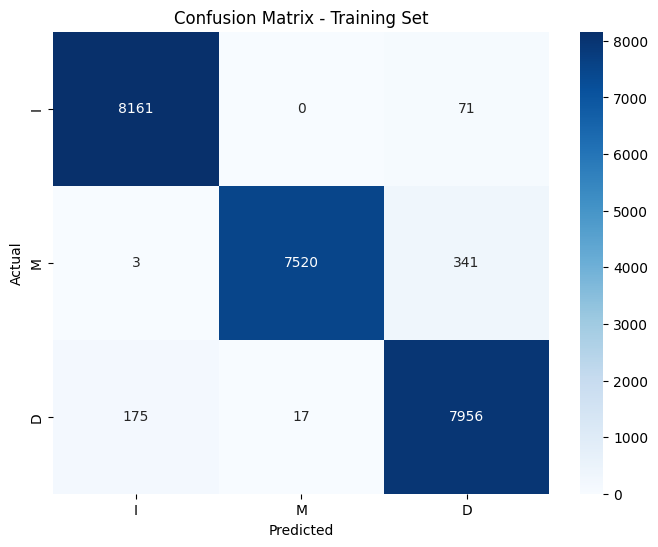


===== Evaluation on Test Set =====
Accuracy: 0.9519
Precision (macro): 0.9540
Recall (macro): 0.9504
F1 Score (macro): 0.9509

Classification Report:
              precision    recall  f1-score   support

           I       0.92      1.00      0.96       416
           M       0.98      0.98      0.98       402
           D       0.97      0.88      0.92       387

    accuracy                           0.95      1205
   macro avg       0.95      0.95      0.95      1205
weighted avg       0.95      0.95      0.95      1205



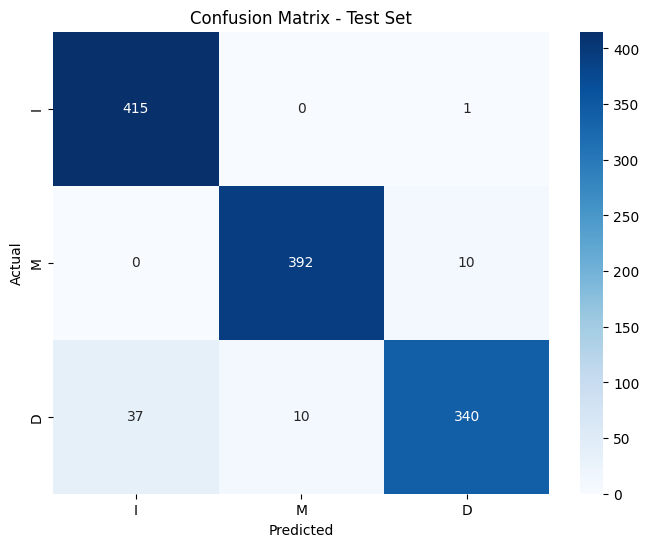


===== Feature Importance =====


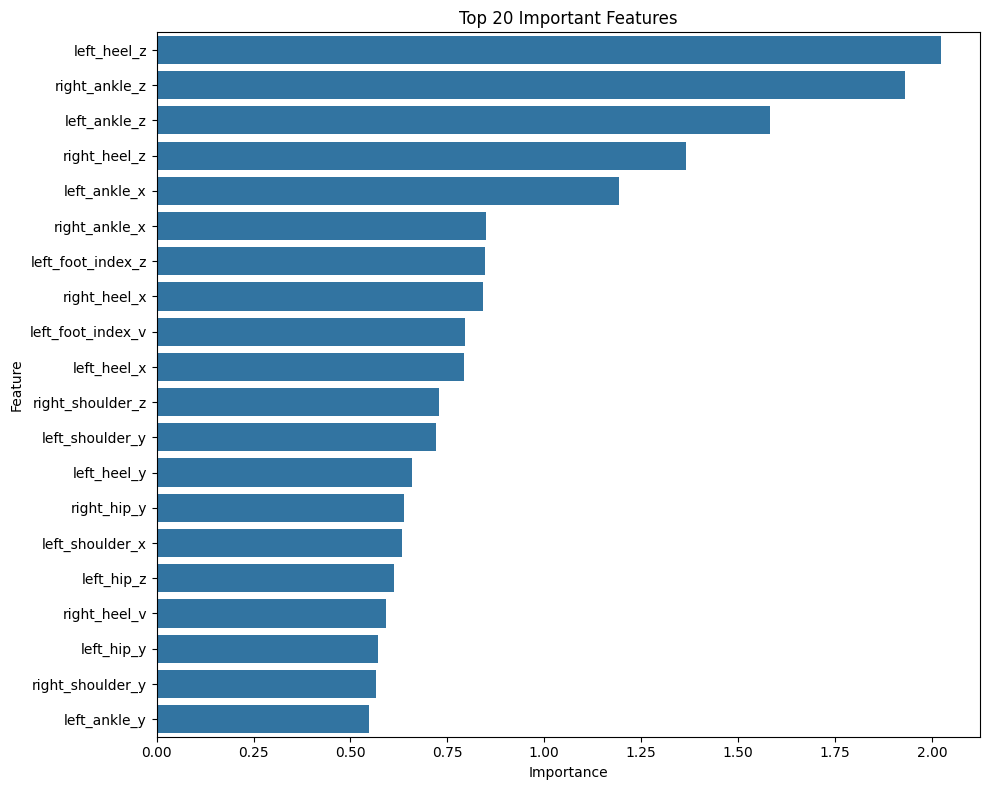


===== Example Usage =====
Initializing pipeline...

Sample input features:
     nose_x    nose_y    nose_z    nose_v  left_shoulder_x  left_shoulder_y  \
0  0.522216  0.167135  0.089144  0.997965         0.490705         0.204090   
1  0.515609  0.192405  0.080005  0.998670         0.482042         0.228061   
2  0.514657  0.193327  0.115741  0.998759         0.482272         0.234828   

   left_shoulder_z  left_shoulder_v  right_shoulder_x  right_shoulder_y  ...  \
0         0.263074         0.996622          0.460292          0.173152  ...   
1         0.241239         0.996511          0.454284          0.190303  ...   
2         0.282573         0.996325          0.454399          0.189583  ...   

   right_heel_z  right_heel_v  left_foot_index_x  left_foot_index_y  \
0     -0.260620      0.927816           0.521558           0.839616   
1     -0.230184      0.928923           0.490633           0.831740   
2     -0.378020      0.929112           0.489992           0.831961   

 

In [ ]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score,
                            confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# ======================
# CONFIGURATION
# ======================
TRAIN_DATA_PATH = "stage.train.csv"
TEST_DATA_PATH = "stage.test.csv"
MODEL_SAVE_PATH = "ridge_lunge_model.pkl"
SCALER_SAVE_PATH = "ridge_lunge_scaler.pkl"
RANDOM_STATE = 42

# ======================
# DATA LOADING & PREPROCESSING
# ======================
def load_data(filepath):
    """Load and validate dataset"""
    df = pd.read_csv(filepath)

    # Basic validation
    assert 'label' in df.columns, "Dataset must contain 'label' column"
    assert len(df.columns) > 1, "Dataset must contain feature columns"

    print(f"\nLoaded data from {filepath}")
    print(f"Shape: {df.shape}")
    print("Label distribution:")
    print(df['label'].value_counts())

    return df

print("===== Loading Datasets =====")
train_df = load_data(TRAIN_DATA_PATH)
test_df = load_data(TEST_DATA_PATH)

# Prepare features and labels
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# ======================
# FEATURE SCALING
# ======================
print("\n===== Feature Scaling =====")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {SCALER_SAVE_PATH}")

# ======================
# MODEL TRAINING
# ======================
print("\n===== Model Training =====")
model = RidgeClassifier(random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)
print("Model training completed")

# Save the model
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved to {MODEL_SAVE_PATH}")

# ======================
# MODEL EVALUATION
# ======================
def evaluate_model(model, X, y, set_name="Test"):
    """Comprehensive model evaluation"""
    y_pred = model.predict(X)

    print(f"\n===== Evaluation on {set_name} Set =====")
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y, y_pred, average='macro'):.4f}")
    print(f"F1 Score (macro): {f1_score(y, y_pred, average='macro'):.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['I', 'M', 'D']))

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['I', 'M', 'D'],
                yticklabels=['I', 'M', 'D'])
    plt.title(f'Confusion Matrix - {set_name} Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return y_pred

print("\n===== Model Evaluation =====")
train_pred = evaluate_model(model, X_train_scaled, y_train, "Training")
test_pred = evaluate_model(model, X_test_scaled, y_test, "Test")

# ======================
# FEATURE IMPORTANCE
# ======================
print("\n===== Feature Importance =====")
def plot_feature_importance(model, feature_names):
    importance = np.abs(model.coef_).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature',
                data=importance_df.head(20))
    plt.title('Top 20 Important Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(model, X_train.columns)

# ======================
# INFERENCE PIPELINE
# ======================
class LungeStageDetector:
    def __init__(self, model_path, scaler_path):
        """Initialize with model and scaler"""
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        self.classes_ = ['I', 'M', 'D']  # Assuming these classes

    def predict(self, features):
        """Predict lunge stage"""
        if isinstance(features, pd.DataFrame):
            features = features.values
        features = self.scaler.transform(features)
        return self.model.predict(features)

    def predict_proba(self, features):
        """Get prediction probabilities"""
        if isinstance(features, pd.DataFrame):
            features = features.values
        features = self.scaler.transform(features)
        decision_values = self.model.decision_function(features)
        proba = np.exp(decision_values)
        return proba / proba.sum(axis=1, keepdims=True)

    def get_feature_importance(self):
        """Get feature importance"""
        return np.abs(self.model.coef_).mean(axis=0)

# ======================
# EXAMPLE USAGE
# ======================
print("\n===== Example Usage =====")
print("Initializing pipeline...")
detector = LungeStageDetector(MODEL_SAVE_PATH, SCALER_SAVE_PATH)

# Simulate new data (in practice, you'd load real new data)
sample_data = X_test.iloc[:3].copy()
print("\nSample input features:")
print(sample_data)

# Make predictions
predictions = detector.predict(sample_data)
probabilities = detector.predict_proba(sample_data)

print("\nPredictions:", predictions)
print("Probabilities:")
print(pd.DataFrame(probabilities, columns=detector.classes_))

print("\n===== Pipeline Execution Complete =====")

## ML Pipeline for error detection

===== Loading Datasets =====

Loaded data from err.train.csv
Shape: (17907, 53)
Label distribution:
label
0    9114
1    8793
Name: count, dtype: int64

Loaded data from err.test.csv
Shape: (1107, 53)
Label distribution:
label
0    561
1    546
Name: count, dtype: int64

===== Feature Scaling =====
Scaler saved to lunge_lr_scaler.pkl

===== Model Training =====
Logistic Regression training completed
Model saved to lunge_lr_model.pkl

===== Model Evaluation =====

===== Evaluation on Training Set =====
Accuracy: 0.9955
Precision (Correct): 0.9956
Recall (Correct): 0.9952
F1 Score (Correct): 0.9954

Classification Report:
              precision    recall  f1-score   support

   Incorrect       1.00      1.00      1.00      9114
     Correct       1.00      1.00      1.00      8793

    accuracy                           1.00     17907
   macro avg       1.00      1.00      1.00     17907
weighted avg       1.00      1.00      1.00     17907



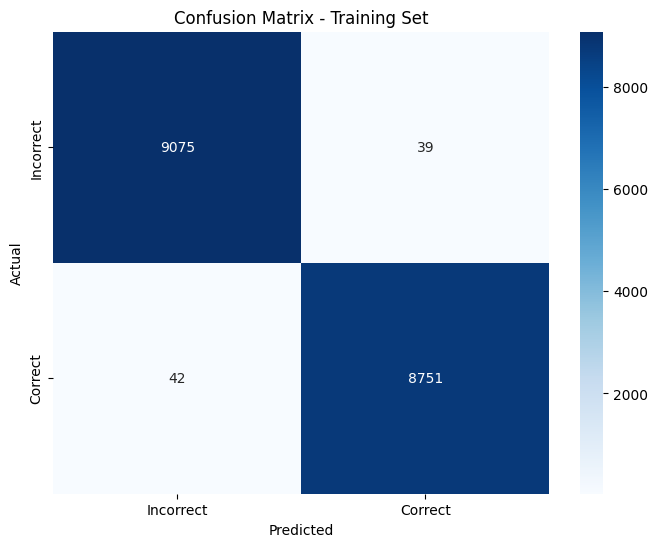


===== Evaluation on Test Set =====
Accuracy: 0.9693
Precision (Correct): 0.9429
Recall (Correct): 0.9982
F1 Score (Correct): 0.9698

Classification Report:
              precision    recall  f1-score   support

   Incorrect       1.00      0.94      0.97       561
     Correct       0.94      1.00      0.97       546

    accuracy                           0.97      1107
   macro avg       0.97      0.97      0.97      1107
weighted avg       0.97      0.97      0.97      1107



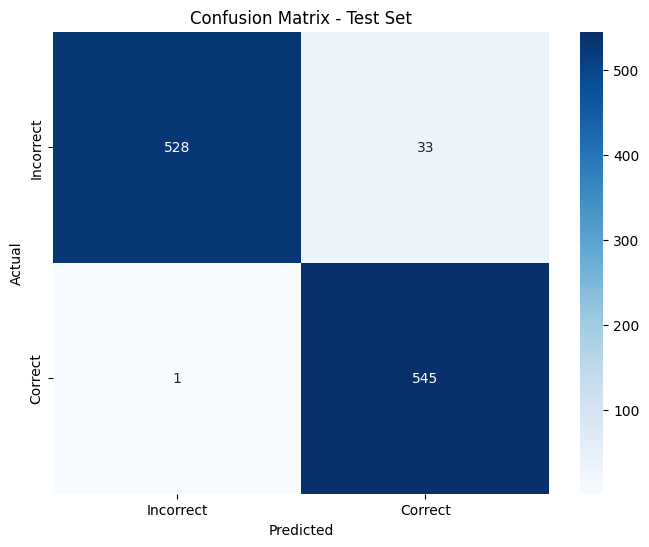


===== Feature Importance =====


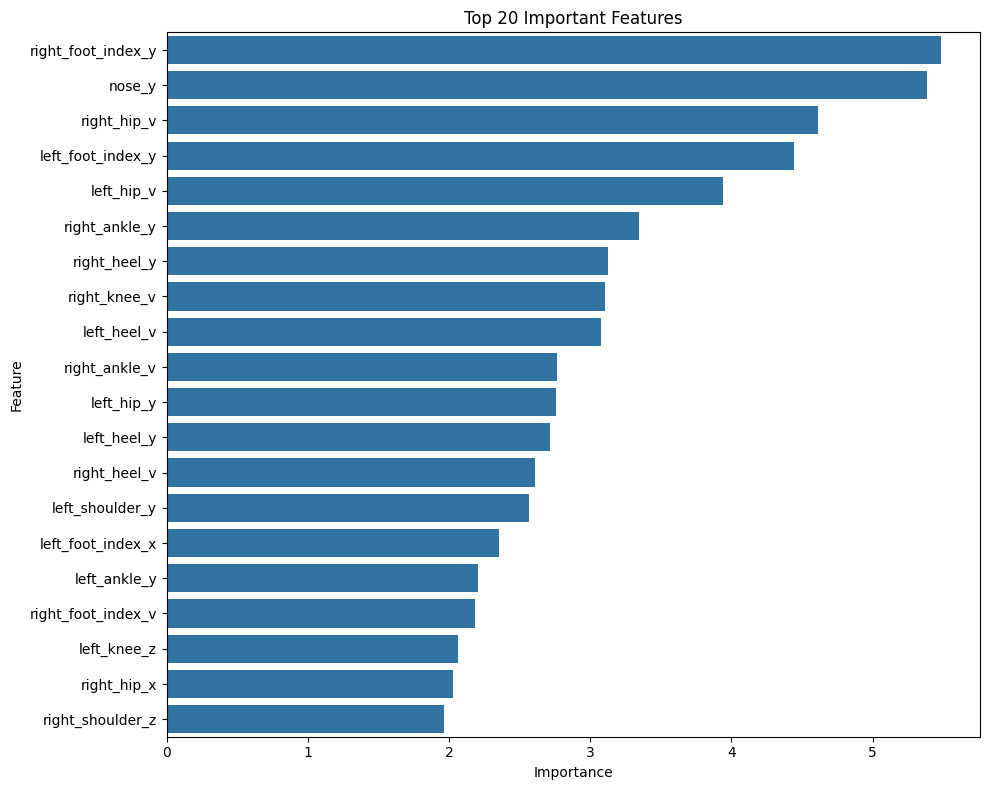


===== Example Usage =====
Initializing pipeline...

Sample input features:
     nose_x    nose_y    nose_z    nose_v  left_shoulder_x  left_shoulder_y  \
0  0.435579  0.495308 -0.036068  0.999907         0.493251         0.462635   
1  0.430779  0.496739 -0.041446  0.999943         0.484919         0.472336   
2  0.429949  0.496562 -0.046910  0.999948         0.484229         0.473008   

   left_shoulder_z  left_shoulder_v  right_shoulder_x  right_shoulder_y  ...  \
0        -0.191836         0.999991          0.486539          0.494380  ...   
1        -0.195461         0.999993          0.483111          0.496463  ...   
2        -0.204609         0.999993          0.482382          0.496268  ...   

   right_heel_z  right_heel_v  left_foot_index_x  left_foot_index_y  \
0      0.220009      0.897805           0.757324           0.852740   
1      0.231633      0.889243           0.762398           0.854807   
2      0.236544      0.888406           0.764201           0.852173   

 

In [ ]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                           recall_score, f1_score,
                           confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# ======================
# CONFIGURATION
# ======================
TRAIN_DATA_PATH = "err.train.csv"
TEST_DATA_PATH = "err.test.csv"
MODEL_SAVE_PATH = "lunge_lr_model.pkl"
SCALER_SAVE_PATH = "lunge_lr_scaler.pkl"
RANDOM_STATE = 42

# ======================
# DATA LOADING & PREPROCESSING
# ======================
def load_and_preprocess_data(filepath):
    """Load dataset and convert labels to binary"""
    df = pd.read_csv(filepath)

    # Convert labels: C (Correct)->1, L (Incorrect)->0
    df['label'] = df['label'].map({'C': 1, 'L': 0})

    print(f"\nLoaded data from {filepath}")
    print(f"Shape: {df.shape}")
    print("Label distribution:")
    print(df['label'].value_counts())

    return df

print("===== Loading Datasets =====")
train_df = load_and_preprocess_data(TRAIN_DATA_PATH)
test_df = load_and_preprocess_data(TEST_DATA_PATH)

# Prepare features and labels
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# ======================
# FEATURE SCALING
# ======================
print("\n===== Feature Scaling =====")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {SCALER_SAVE_PATH}")

# ======================
# MODEL TRAINING
# ======================
print("\n===== Model Training =====")
lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,  # Increased for convergence
    class_weight='balanced'  # Handles class imbalance
)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression training completed")

# Save the model
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"Model saved to {MODEL_SAVE_PATH}")

# ======================
# MODEL EVALUATION
# ======================
def evaluate_model(model, X, y, set_name="Test"):
    """Comprehensive model evaluation"""
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]  # Probability of class 1 (Correct form)

    print(f"\n===== Evaluation on {set_name} Set =====")
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"Precision (Correct): {precision_score(y, y_pred, pos_label=1):.4f}")
    print(f"Recall (Correct): {recall_score(y, y_pred, pos_label=1):.4f}")
    print(f"F1 Score (Correct): {f1_score(y, y_pred, pos_label=1):.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['Incorrect', 'Correct']))

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Incorrect', 'Correct'],
                yticklabels=['Incorrect', 'Correct'])
    plt.title(f'Confusion Matrix - {set_name} Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return y_pred, y_proba

print("\n===== Model Evaluation =====")
# Training set evaluation
train_pred, train_proba = evaluate_model(lr_model, X_train_scaled, y_train, "Training")

# Test set evaluation
test_pred, test_proba = evaluate_model(lr_model, X_test_scaled, y_test, "Test")

# ======================
# FEATURE IMPORTANCE
# ======================
print("\n===== Feature Importance =====")
def plot_feature_importance(model, feature_names):
    """Plot logistic regression coefficients"""
    importance = np.abs(model.coef_[0])
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature',
                data=importance_df.head(20))
    plt.title('Top 20 Important Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(lr_model, X_train.columns)

# ======================
# INFERENCE PIPELINE
# ======================
class LungeFormClassifier:
    def __init__(self, model_path, scaler_path):
        """Initialize classifier with model and scaler"""
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)

    def predict(self, features):
        """Predict lunge form (0=Incorrect, 1=Correct)"""
        if isinstance(features, pd.DataFrame):
            features = features.values
        features = self.scaler.transform(features)
        return self.model.predict(features)

    def predict_proba(self, features):
        """Get probability of correct form"""
        if isinstance(features, pd.DataFrame):
            features = features.values
        features = self.scaler.transform(features)
        return self.model.predict_proba(features)[:, 1]  # Probability of class 1 (Correct)

    def get_feature_importance(self):
        """Get feature importance scores"""
        return pd.DataFrame({
            'Feature': X_train.columns,
            'Coefficient': self.model.coef_[0],
            'Absolute_Importance': np.abs(self.model.coef_[0])
        }).sort_values('Absolute_Importance', ascending=False)

# ======================
# EXAMPLE USAGE
# ======================
print("\n===== Example Usage =====")
print("Initializing pipeline...")
classifier = LungeFormClassifier(MODEL_SAVE_PATH, SCALER_SAVE_PATH)

# Example: Predict on first 3 test samples
sample_data = X_test.iloc[:3].copy()
print("\nSample input features:")
print(sample_data)

# Make predictions
predictions = classifier.predict(sample_data)
probabilities = classifier.predict_proba(sample_data)

print("\nPredictions:", ["Incorrect" if p == 0 else "Correct" for p in predictions])
print("Probabilities of correct form:", probabilities)

print("\n===== Pipeline Execution Complete =====")

## Video input testing

In [ ]:
!pip install mediapipe

  Using cached mediapipe-0.10.21-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached mediapipe-0.10.21-cp311-cp311-manylinux_2_28_x86_64.whl (35.6 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import cv2
import pickle
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import time

mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

def calculate_angle(a, b, c):
    """Calculate the angle between three points"""
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

def extract_important_keypoints(results, important_landmarks):
    """Extract important landmarks from MediaPipe results"""
    pose = mp_pose.PoseLandmark
    row = []

    for landmark in important_landmarks:
        landmark = pose[landmark].value
        landmark = results.pose_landmarks.landmark[landmark]
        row.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

    return row

class LungeDetection:
    STAGE_ML_MODEL_PATH = "model/lunge_stage_model.pkl"
    ERR_ML_MODEL_PATH = "model/lunge_err_model.pkl"
    INPUT_SCALER_PATH = "model/lunge_input_scaler.pkl"

    PREDICTION_PROB_THRESHOLD = 0.8
    KNEE_ANGLE_THRESHOLD = [60, 125]

    def __init__(self) -> None:
        self.init_important_landmarks()
        self.load_machine_learning_model()

        self.current_stage = ""
        self.counter = 0
        self.results = []
        self.has_error = False
        self.right_knee_pos = None
        self.left_knee_pos = None

    def init_important_landmarks(self) -> None:
        """Determine Important landmarks for lunge detection"""
        self.important_landmarks = [
            "NOSE",
            "LEFT_SHOULDER",
            "RIGHT_SHOULDER",
            "LEFT_HIP",
            "RIGHT_HIP",
            "LEFT_KNEE",
            "RIGHT_KNEE",
            "LEFT_ANKLE",
            "RIGHT_ANKLE",
            "LEFT_HEEL",
            "RIGHT_HEEL",
            "LEFT_FOOT_INDEX",
            "RIGHT_FOOT_INDEX",
        ]

        # Generate all columns of the data frame
        self.headers = ["label"]  # Label column

        for lm in self.important_landmarks:
            self.headers += [
                f"{lm.lower()}_x",
                f"{lm.lower()}_y",
                f"{lm.lower()}_z",
                f"{lm.lower()}_v",
            ]

    def load_machine_learning_model(self) -> None:
        """Load machine learning model"""
        if (not Path(self.STAGE_ML_MODEL_PATH).exists() or
            not Path(self.INPUT_SCALER_PATH).exists() or
            not Path(self.ERR_ML_MODEL_PATH).exists()):
            raise Exception("Cannot find lunge model files for prediction")

        try:
            with open(self.ERR_ML_MODEL_PATH, "rb") as f:
                self.err_model = pickle.load(f)

            with open(self.STAGE_ML_MODEL_PATH, "rb") as f:
                self.stage_model = pickle.load(f)

            with open(self.INPUT_SCALER_PATH, "rb") as f2:
                self.input_scaler = pickle.load(f2)
        except Exception as e:
            raise Exception(f"Error loading model, {e}")

    def analyze_knee_angle(self, mp_results, stage: str, angle_thresholds: list, knee_over_toe: bool = False):
        """Calculate angle of each knee while performer at the DOWN position"""
        results = {
            "error": None,
            "right": {"error": None, "angle": None},
            "left": {"error": None, "angle": None},
        }

        landmarks = mp_results.pose_landmarks.landmark

        # Calculate right knee angle and position
        right_hip = [
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y,
        ]
        self.right_knee_pos = [
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y,
        ]
        right_ankle = [
            landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y,
        ]
        results["right"]["angle"] = calculate_angle(right_hip, self.right_knee_pos, right_ankle)

        # Calculate left knee angle and position
        left_hip = [
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y,
        ]
        self.left_knee_pos = [
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y,
        ]
        left_ankle = [
            landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y,
        ]
        results["left"]["angle"] = calculate_angle(left_hip, self.left_knee_pos, left_ankle)

        if stage != "down":
            return results

        # Ignore checking for knee angle error if knee_over_toe error occurs
        if knee_over_toe:
            return results

        # Evaluation
        results["error"] = False

        if angle_thresholds[0] <= results["right"]["angle"] <= angle_thresholds[1]:
            results["right"]["error"] = False
        else:
            results["right"]["error"] = True
            results["error"] = True

        if angle_thresholds[0] <= results["left"]["angle"] <= angle_thresholds[1]:
            results["left"]["error"] = False
        else:
            results["left"]["error"] = True
            results["error"] = True

        return results

    def clear_results(self) -> None:
        self.results = []
        self.counter = 0
        self.current_stage = ""
        self.has_error = False

    def detect(self, mp_results, image, timestamp) -> None:
        """Make Lunge Errors detection"""
        try:
            video_dimensions = [image.shape[1], image.shape[0]]

            # Model prediction for LUNGE counter
            row = extract_important_keypoints(mp_results, self.important_landmarks)
            X = pd.DataFrame([row], columns=self.headers[1:])
            X = pd.DataFrame(self.input_scaler.transform(X))

            # Make prediction and its probability
            stage_predicted_class = self.stage_model.predict(X)[0]
            stage_prediction_probabilities = self.stage_model.predict_proba(X)[0]
            stage_prediction_probability = round(
                stage_prediction_probabilities[stage_prediction_probabilities.argmax()],
                2,
            )

            # Evaluate stage prediction for counter
            if (
                stage_predicted_class == "I"
                and stage_prediction_probability >= self.PREDICTION_PROB_THRESHOLD
            ):
                self.current_stage = "init"
            elif (
                stage_predicted_class == "M"
                and stage_prediction_probability >= self.PREDICTION_PROB_THRESHOLD
            ):
                self.current_stage = "mid"
            elif (
                stage_predicted_class == "D"
                and stage_prediction_probability >= self.PREDICTION_PROB_THRESHOLD
            ):
                if self.current_stage in ["init", "mid"]:
                    self.counter += 1
                self.current_stage = "down"

            # Analyze lunge pose - Knee over toe
            k_o_t_error = None
            if self.current_stage == "down":
                err_predicted_class = self.err_model.predict(X)[0]
                err_prediction_probabilities = self.err_model.predict_proba(X)[0]
                err_prediction_probability = round(
                    err_prediction_probabilities[err_prediction_probabilities.argmax()],
                    2,
                )

                if (
                    err_predicted_class == "L"
                    and err_prediction_probability >= self.PREDICTION_PROB_THRESHOLD
                ):
                    k_o_t_error = True
                    self.has_error = True
                elif (
                    err_predicted_class == "C"
                    and err_prediction_probability >= self.PREDICTION_PROB_THRESHOLD
                ):
                    k_o_t_error = False
                    self.has_error = False
            else:
                self.has_error = False

            # Analyze knee angle
            analyzed_results = self.analyze_knee_angle(
                mp_results=mp_results,
                stage=self.current_stage,
                angle_thresholds=self.KNEE_ANGLE_THRESHOLD,
                knee_over_toe=k_o_t_error,
            )

            # Determine if current rep is correct
            if self.current_stage == "down":
                self.has_error = analyzed_results["error"] if not self.has_error else self.has_error

            # Visualization
            # Draw landmarks and connections
            landmark_color = (0, 0, 255) if self.has_error else (0, 255, 0)
            connection_color = (0, 0, 255) if self.has_error else (0, 255, 0)

            mp_drawing.draw_landmarks(
                image,
                mp_results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=landmark_color, thickness=2, circle_radius=2),
                mp_drawing.DrawingSpec(color=connection_color, thickness=2, circle_radius=1),
            )

            # Create a black translucent overlay for metrics
            overlay = image.copy()
            cv2.rectangle(overlay, (0, 0), (image.shape[1], 40), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.7, image, 0.3, 0, image)

            # Display simplified metrics in white text at top-center
            status_text = "CORRECT" if not self.has_error else "INCORRECT"
            status_color = (255, 255, 255) if not self.has_error else (0, 0, 255)

            cv2.putText(
                image,
                f"REPS: {self.counter} | STATUS: {status_text}",
                (image.shape[1]//2 - 150, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                status_color,
                2,
                cv2.LINE_AA,
            )

            # Display knee angles near the knees if available
            if self.right_knee_pos and analyzed_results["right"]["angle"] is not None:
                cv2.putText(
                    image,
                    str(int(analyzed_results["right"]["angle"])),
                    tuple(np.multiply(self.right_knee_pos, video_dimensions).astype(int)),
                    cv2.FONT_HERSHEY_COMPLEX,
                    0.5,
                    (255, 0, 0) if analyzed_results["right"]["error"] else (255, 255, 255),
                    1,
                    cv2.LINE_AA,
                )

            if self.left_knee_pos and analyzed_results["left"]["angle"] is not None:
                cv2.putText(
                    image,
                    str(int(analyzed_results["left"]["angle"])),
                    tuple(np.multiply(self.left_knee_pos, video_dimensions).astype(int)),
                    cv2.FONT_HERSHEY_COMPLEX,
                    0.5,
                    (255, 0, 0) if analyzed_results["left"]["error"] else (255, 255, 255),
                    1,
                    cv2.LINE_AA,
                )

        except Exception as e:
            print(f"Error while detecting lunge errors: {e}")

def process_video(input_path, output_path):
    """Process video file and save output with progress display"""
    # Initialize video capture
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Error opening video file: {input_path}")
        return

    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Initialize video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    # Initialize MediaPipe Pose with 0.5 detection confidence
    pose = mp_pose.Pose(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    # Initialize Lunge Detection
    lunge_detector = LungeDetection()

    # Start processing
    start_time = time.time()
    processed_frames = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        # Make detection with 0.5 confidence threshold
        results = pose.process(image)

        # Recolor back to BGR
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Lunge detection logic
        if results.pose_landmarks:
            timestamp = cap.get(cv2.CAP_PROP_POS_MSEC)
            lunge_detector.detect(results, image, timestamp)

        # Write frame to output video
        out.write(image)

        # Update progress
        processed_frames += 1
        progress = (processed_frames / total_frames) * 100
        elapsed_time = time.time() - start_time
        fps = processed_frames / elapsed_time if elapsed_time > 0 else 0

        # Update progress in terminal
        sys.stdout.write(f"\rProcessing: {progress:.1f}% | Frames: {processed_frames}/{total_frames} | FPS: {fps:.1f} | Reps: {lunge_detector.counter}")
        sys.stdout.flush()

    # Clean up
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    # Print final results
    print(f"\n\nProcessing complete!")
    print(f"Output saved to: {output_path}")
    print(f"Total lunges counted: {lunge_detector.counter}")
    print("Errors detected:")
    for error in lunge_detector.results:
        print(f"- {error['stage']} at {error['timestamp']}ms (rep {error['counter']})")

if __name__ == "__main__":
    process_video("input.mp4", "output.mp4")

Starting lunge detection video processing...
Models loaded successfully
Processing video: 1920x1080 @ 30.00094046835324 FPS, 638 frames


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

Progress: 4.7% (30/638)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

Progress: 9.4% (60/638)


...

Progress: 94.0% (600/638)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

Progress: 98.7% (630/638)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

Video processing complete. Output saved to: output.mp4

=== PROCESSING COMPLETE ===
Total reps detected: 0
Output video: output.mp4
ML models: Loaded
Download link created successfully!


## Camera input testing

In [ ]:
import cv2
import pickle
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path

mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

def calculate_angle(a, b, c):
    """Calculate the angle between three points"""
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

def extract_important_keypoints(results, important_landmarks):
    """Extract important landmarks from MediaPipe results"""
    pose = mp_pose.PoseLandmark
    row = []

    for landmark in important_landmarks:
        landmark = pose[landmark].value
        landmark = results.pose_landmarks.landmark[landmark]
        row.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

    return row

class LungeDetection:
    STAGE_ML_MODEL_PATH = "model/lunge_stage_model.pkl"
    ERR_ML_MODEL_PATH = "model/lunge_err_model.pkl"
    INPUT_SCALER_PATH = "model/lunge_input_scaler.pkl"

    PREDICTION_PROB_THRESHOLD = 0.8
    KNEE_ANGLE_THRESHOLD = [60, 125]

    def __init__(self) -> None:
        self.init_important_landmarks()
        self.load_machine_learning_model()

        self.current_stage = ""
        self.counter = 0
        self.results = []
        self.has_error = False
        self.right_knee_pos = None
        self.left_knee_pos = None

    def init_important_landmarks(self) -> None:
        """Determine Important landmarks for lunge detection"""
        self.important_landmarks = [
            "NOSE",
            "LEFT_SHOULDER",
            "RIGHT_SHOULDER",
            "LEFT_HIP",
            "RIGHT_HIP",
            "LEFT_KNEE",
            "RIGHT_KNEE",
            "LEFT_ANKLE",
            "RIGHT_ANKLE",
            "LEFT_HEEL",
            "RIGHT_HEEL",
            "LEFT_FOOT_INDEX",
            "RIGHT_FOOT_INDEX",
        ]

        # Generate all columns of the data frame
        self.headers = ["label"]  # Label column

        for lm in self.important_landmarks:
            self.headers += [
                f"{lm.lower()}_x",
                f"{lm.lower()}_y",
                f"{lm.lower()}_z",
                f"{lm.lower()}_v",
            ]

    def load_machine_learning_model(self) -> None:
        """Load machine learning model"""
        if (not Path(self.STAGE_ML_MODEL_PATH).exists() or
            not Path(self.INPUT_SCALER_PATH).exists() or
            not Path(self.ERR_ML_MODEL_PATH).exists()):
            raise Exception("Cannot find lunge model files for prediction")

        try:
            with open(self.ERR_ML_MODEL_PATH, "rb") as f:
                self.err_model = pickle.load(f)

            with open(self.STAGE_ML_MODEL_PATH, "rb") as f:
                self.stage_model = pickle.load(f)

            with open(self.INPUT_SCALER_PATH, "rb") as f2:
                self.input_scaler = pickle.load(f2)
        except Exception as e:
            raise Exception(f"Error loading model, {e}")

    def analyze_knee_angle(self, mp_results, stage: str, angle_thresholds: list, knee_over_toe: bool = False):
        """Calculate angle of each knee while performer at the DOWN position"""
        results = {
            "error": None,
            "right": {"error": None, "angle": None},
            "left": {"error": None, "angle": None},
        }

        landmarks = mp_results.pose_landmarks.landmark

        # Calculate right knee angle and position
        right_hip = [
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y,
        ]
        self.right_knee_pos = [
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y,
        ]
        right_ankle = [
            landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x,
            landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y,
        ]
        results["right"]["angle"] = calculate_angle(right_hip, self.right_knee_pos, right_ankle)

        # Calculate left knee angle and position
        left_hip = [
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y,
        ]
        self.left_knee_pos = [
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y,
        ]
        left_ankle = [
            landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x,
            landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y,
        ]
        results["left"]["angle"] = calculate_angle(left_hip, self.left_knee_pos, left_ankle)

        if stage != "down":
            return results

        # Ignore checking for knee angle error if knee_over_toe error occurs
        if knee_over_toe:
            return results

        # Evaluation
        results["error"] = False

        if angle_thresholds[0] <= results["right"]["angle"] <= angle_thresholds[1]:
            results["right"]["error"] = False
        else:
            results["right"]["error"] = True
            results["error"] = True

        if angle_thresholds[0] <= results["left"]["angle"] <= angle_thresholds[1]:
            results["left"]["error"] = False
        else:
            results["left"]["error"] = True
            results["error"] = True

        return results

    def detect(self, mp_results, image):
        """Make Lunge Errors detection"""
        try:
            video_dimensions = [image.shape[1], image.shape[0]]

            # Model prediction
            row = extract_important_keypoints(mp_results, self.important_landmarks)
            X = pd.DataFrame([row], columns=self.headers[1:])
            X = pd.DataFrame(self.input_scaler.transform(X))

            # Stage prediction
            stage_predicted_class = self.stage_model.predict(X)[0]
            stage_prediction_prob = self.stage_model.predict_proba(X)[0].max()

            # Update stage and counter
            if stage_prediction_prob >= self.PREDICTION_PROB_THRESHOLD:
                if stage_predicted_class == "D" and self.current_stage in ["init", "mid"]:
                    self.counter += 1
                self.current_stage = {"I": "init", "M": "mid", "D": "down"}[stage_predicted_class]

            # Error detection (only in 'down' stage)
            self.has_error = False
            if self.current_stage == "down":
                err_predicted_class = self.err_model.predict(X)[0]
                err_prediction_prob = self.err_model.predict_proba(X)[0].max()

                if err_prediction_prob >= self.PREDICTION_PROB_THRESHOLD:
                    self.has_error = (err_predicted_class == "L")

            # Knee angle analysis
            analyzed_results = self.analyze_knee_angle(
                mp_results=mp_results,
                stage=self.current_stage,
                angle_thresholds=self.KNEE_ANGLE_THRESHOLD,
                knee_over_toe=self.has_error
            )

            # Update error status
            if self.current_stage == "down":
                self.has_error = self.has_error or analyzed_results["error"]

            # Visualization
            # 1. Draw pose landmarks
            mp_drawing.draw_landmarks(
                image,
                mp_results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(0, 0, 255) if self.has_error else (0, 255, 0)),
                mp_drawing.DrawingSpec(color=(0, 0, 255) if self.has_error else (0, 255, 0))
            )

            # 2. Create black translucent overlay
            overlay = image.copy()
            cv2.rectangle(overlay, (0, 0), (image.shape[1], 60), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.7, image, 0.3, 0, image)

            # 3. Display metrics (WHITE TEXT)
            cv2.putText(
                image,
                f"REPS: {self.counter} | STATUS: {'CORRECT' if not self.has_error else 'INCORRECT'}",
                (image.shape[1]//2 - 150, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),  # WHITE
                2,
                cv2.LINE_AA,
            )

            # 4. Display knee angles
            if self.right_knee_pos and analyzed_results["right"]["angle"]:
                cv2.putText(
                    image,
                    str(int(analyzed_results["right"]["angle"])),
                    tuple(np.multiply(self.right_knee_pos, video_dimensions).astype(int)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 255, 255),
                    1,
                    cv2.LINE_AA,
                )

            if self.left_knee_pos and analyzed_results["left"]["angle"]:
                cv2.putText(
                    image,
                    str(int(analyzed_results["left"]["angle"])),
                    tuple(np.multiply(self.left_knee_pos, video_dimensions).astype(int)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 255, 255),
                    1,
                    cv2.LINE_AA,
                )

        except Exception as e:
            print(f"Detection error: {e}")

def main():
    # Initialize camera
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    # Initialize Pose detection
    pose = mp_pose.Pose(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    # Initialize Lunge detector
    detector = LungeDetection()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Process frame
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Detect lunges if pose found
        if results.pose_landmarks:
            detector.detect(results, image)

        # Display
        cv2.imshow('Lunge Trainer', image)

        # Exit on 'q'
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"Final rep count: {detector.counter}")

if __name__ == "__main__":
    main()